<a href="https://colab.research.google.com/github/ARASHFAQUE/hit-140-assessment-2-presentation/blob/main/HIT.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

1. TITLE
ANALYTIC TASK - SHOOTING PERFORMANCE
FIFA WORLD CUP 2026 PLAYER SHOOTING ANALYSIS

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("Libraries imported successfully.")

Libraries imported successfully.


2. Analytic Question:

Is there a statistically significant difference in the mean shots on target per 90 minutes (SoT/90) between forwards and midfielders in the FIFA World Cup 2026?

The SoT/90 is chosen for the analysis of the shooting performance of the players, as this variable measures the frequency of shots on target of a player, and also takes into account the playing time of the player for that match.


3.⁠ Data Source

FBref provided the player-level shooting data for the FIFA World Cup 2026. The data included several variables to describe a player’s shooting including his total goals, his total shots, his total shots on target, and finally how he performed for shots on target per 90 minutes for all shots he took. In addition to the data for a player’s shooting, FBref provided data regarding a number of other variables including a player’s name, position, the squad/team for which he played, the player’s age, and the player’s total playing time for the tournament in minutes.


In [ ]:
df = pd.read_csv(
    "/content/shooting 2.csv",
    encoding="cp1252",
    skiprows=1
)

df.head()

,Rk,Player,Pos,Squad,Age,Born,90s,Gls,Sh,SoT,SoT%,Sh/90,SoT/90,G/Sh,G/SoT,PK,PKatt,Matches
0,1,Brenden Aaronson,MF,us USA,25,2000,0.8,0,3,1,33.3,3.55,1.18,0,0,0,0,Matches
1,2,Thelo Aasgaard,MF,no Norway,24,2002,1,1,2,1,50,2,1,0.5,1,0,0,Matches
2,3,Hamza Abdelkarim,FW,eg Egypt,18,2008,0.7,0,0,0,NaN,0,0,NaN,NaN,0,0,Matches
3,4,Hossam Abdelmaguid,DF,eg Egypt,25,2001,0.7,0,0,0,NaN,0,0,NaN,NaN,0,0,Matches
4,5,Mohamed Abdelmonem,DF,eg Egypt,27,1999,0.2,0,0,0,NaN,0,0,NaN,NaN,0,0,Matches


4. Data Wrangling

The data imported into Python with the use of Pandas tool has gone through initial inspection in order to check the structure of the data set, look into variables used in the data set and to see whether any processing is required prior to analysis.


In [ ]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 1080
Number of columns: 18


In [ ]:
print(df.columns.tolist())

['Rk', 'Player', 'Pos', 'Squad', 'Age', 'Born', '90s', 'Gls', 'Sh', 'SoT', 'SoT%', 'Sh/90', 'SoT/90', 'G/Sh', 'G/SoT', 'PK', 'PKatt', 'Matches']


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1080 entries, 0 to 1079
Data columns (total 18 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   Rk       1080 non-null   object
 1   Player   1080 non-null   object
 2   Pos      1080 non-null   object
 3   Squad    1080 non-null   object
 4   Age      1080 non-null   object
 5   Born     1080 non-null   object
 6   90s      1080 non-null   object
 7   Gls      1080 non-null   object
 8   Sh       1080 non-null   object
 9   SoT      1080 non-null   object
 10  SoT%     721 non-null    object
 11  Sh/90    1080 non-null   object
 12  SoT/90   1080 non-null   object
 13  G/Sh     721 non-null    object
 14  G/SoT    437 non-null    object
 15  PK       1080 non-null   object
 16  PKatt    1080 non-null   object
 17  Matches  1080 non-null   object
dtypes: object(18)
memory usage: 152.0+ KB


In [ ]:

shooting = df.copy()

# To remove repeated header rows that may appear inside the FBref table
shooting = shooting[shooting["Player"] != "Player"].copy()

# To remove ranking and Matches because they are not needed for our analysis
shooting = shooting.drop(columns=["Rk", "Matches"])

# Columns that should contain numbers
numeric_cols = [
    "Age", "Born", "90s", "Gls", "Sh", "SoT",
    "SoT%", "Sh/90", "SoT/90", "G/Sh",
    "G/SoT", "PK", "PKatt"
]

# Convert them from text to numeric
for col in numeric_cols:
    shooting[col] = pd.to_numeric(shooting[col], errors="coerce")

print("Cleaned dataset shape:", shooting.shape)
shooting.info()

Cleaned dataset shape: (1039, 16)
<class 'pandas.core.frame.DataFrame'>
Index: 1039 entries, 0 to 1079
Data columns (total 16 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Player  1039 non-null   object 
 1   Pos     1039 non-null   object 
 2   Squad   1039 non-null   object 
 3   Age     1039 non-null   int64  
 4   Born    1039 non-null   int64  
 5   90s     1039 non-null   float64
 6   Gls     1039 non-null   int64  
 7   Sh      1039 non-null   int64  
 8   SoT     1039 non-null   int64  
 9   SoT%    680 non-null    float64
 10  Sh/90   1039 non-null   float64
 11  SoT/90  1039 non-null   float64
 12  G/Sh    680 non-null    float64
 13  G/SoT   396 non-null    float64
 14  PK      1039 non-null   int64  
 15  PKatt   1039 non-null   int64  
dtypes: float64(6), int64(7), object(3)
memory usage: 138.0+ KB


5. Data Cleaning

The dataset has been inspected for missing values and for duplicate records of player’s shooting statistics. Some rate-based shooting statistics contain missing values for players for whom the relevant statistic cannot be calculated. These have been taken into consideration when choosing the shooting variable for this analysis.



In [ ]:
shooting.isnull().sum()

,0
Player,0
Pos,0
Squad,0
Age,0
Born,0
90s,0
Gls,0
Sh,0
SoT,0
SoT%,359


In [ ]:
print("Duplicate rows:", shooting.duplicated().sum())

Duplicate rows: 0


There were no duplicate player records. Other shooting efficiency variables had some missing values. However, SoT/90 for the selected players had all the required observations for this analysis.



6.⁠ ⁠Player Selection:

Population and Player Selection

The analysis compares players with recorded position FW (forward) to players with recorded position MF (midfielder). Players with combined positions were excluded from the analysis to keep the two groups under study clearly separated.


In [ ]:
print(shooting["Pos"].value_counts())

Pos
MF       344
DF       306
FW       159
FW,MF     77
GK        62
DF,MF     40
MF,FW     36
MF,DF     12
DF,FW      3
Name: count, dtype: int64


In [ ]:
# Keep only players listed exclusively as forwards or midfielders
population = shooting[shooting["Pos"].isin(["FW", "MF"])].copy()

print("Total eligible players:", len(population))
print("\nPlayers by position:")
print(population["Pos"].value_counts())

Total eligible players: 503

Players by position:
Pos
MF    344
FW    159
Name: count, dtype: int64


In [ ]:
eligible = population[population["90s"] >= 1.0].copy()

print("Eligible players after minimum playing-time rule:", len(eligible))
print("\nEligible players by position:")
print(eligible["Pos"].value_counts())

Eligible players after minimum playing-time rule: 353

Eligible players by position:
Pos
MF    254
FW     99
Name: count, dtype: int64


Players with less than 1.0 90s have been excluded from the analysis as well. As a result all players in the end analyze games where they played for more than approximately 90 minutes in order to prevent extreme values caused by very low playing time in the per-90 statistics.

Our resulting eligible groups were:

After applying these criteria, the size of the eligible set of players is 99 (Forwards) + 254 (Midfielders) = 353 players, with 99 of them being Forwards and 254 of them being Midfielders.


In [ ]:
forwards = eligible[eligible["Pos"] == "FW"]
midfielders = eligible[eligible["Pos"] == "MF"]

print("Forwards:", len(forwards))
print("Midfielders:", len(midfielders))

print("\nForward SoT/90 summary:")
print(forwards["SoT/90"].describe())

print("\nMidfielder SoT/90 summary:")
print(midfielders["SoT/90"].describe())

Forwards: 99
Midfielders: 254

Forward SoT/90 summary:
count    99.000000
mean      0.870505
std       0.737096
min       0.000000
25%       0.000000
50%       0.760000
75%       1.405000
max       2.980000
Name: SoT/90, dtype: float64

Midfielder SoT/90 summary:
count    254.000000
mean       0.408110
std        0.487638
min        0.000000
25%        0.000000
50%        0.305000
75%        0.640000
max        2.090000
Name: SoT/90, dtype: float64


7.⁠ Data Preparation and Sampling:
I ran a simple random sample of 50 eligible forwards and 50 eligible midfielders for this analysis. The method of random sampling ensures all eligible players have an equal chance to be selected, as opposed to me manually selecting certain players for this analysis. The fixed random state of 42 ensures that I can re-run the code in this notebook and get to reproduce the same sample.


In [ ]:
# Random sampling with a fixed seed for reproducibility
forward_sample = forwards.sample(n=50, random_state=42)
midfielder_sample = midfielders.sample(n=50, random_state=42)

print("Forward sample size:", len(forward_sample))
print("Midfielder sample size:", len(midfielder_sample))

Forward sample size: 50
Midfielder sample size: 50


In [ ]:
print("FORWARD SAMPLE")
print(forward_sample[["Player", "Squad", "90s", "SoT/90"]].head(10))

print("\nMIDFIELDER SAMPLE")
print(midfielder_sample[["Player", "Squad", "90s", "SoT/90"]].head(10))

FORWARD SAMPLE
               Player              Squad  90s  SoT/90
702      Darwin Núñez         uy Uruguay  1.7    0.00
451     Wilson Isidor           ht Haiti  2.1    0.97
1020   Federico Viñas         uy Uruguay  2.1    1.41
227     Matheus Cunha          br Brazil  3.2    1.55
1045      Yoane Wissa        cd Congo DR  4.0    0.75
937        Pavel Šulc         cz Czechia  2.1    0.00
720    Tani Oluwaseyi          ca Canada  2.9    1.39
460      Lee Jae-sung  kr Korea Republic  1.3    0.77
147   Ange-Yoan Bonny   ci Côte d'Ivoire  2.6    0.38
8     Yusuf Abdurisag           qa Qatar  1.1    0.00

MIDFIELDER SAMPLE
                   Player             Squad  90s  SoT/90
800      Noor Al Rawabdeh         jo Jordan  3.0    0.00
46    Khojiakbar Alijonov     uz Uzbekistan  1.5    0.00
321        Álvaro Fidalgo         mx Mexico  1.1    1.87
861       Ibrahim Sangaré  ci Côte d'Ivoire  3.0    0.00
502  Abdullah Al-Khaibari   sa Saudi Arabia  2.0    0.00
778     Christian Pulisic     

In [ ]:
print("Forward sample statistics:")
print(forward_sample["SoT/90"].describe())

print("\nMidfielder sample statistics:")
print(midfielder_sample["SoT/90"].describe())

Forward sample statistics:
count    50.000000
mean      0.813400
std       0.695726
min       0.000000
25%       0.000000
50%       0.755000
75%       1.355000
max       2.520000
Name: SoT/90, dtype: float64

Midfielder sample statistics:
count    50.000000
mean      0.443200
std       0.563268
min       0.000000
25%       0.000000
50%       0.290000
75%       0.677500
max       1.870000
Name: SoT/90, dtype: float64


8.⁠ Descriptive Statistics

To examine the central tendency and variability of SoT/90 in both groups prior to drawing conclusions via inferential statistics, descriptive statistics were also computed for each position group.


In [ ]:
summary = pd.DataFrame({
    "Forwards": forward_sample["SoT/90"].describe(),
    "Midfielders": midfielder_sample["SoT/90"].describe()
})

summary

,Forwards,Midfielders
count,50.000000,50.000000
mean,0.813400,0.443200
std,0.695726,0.563268
min,0.000000,0.000000
25%,0.000000,0.000000
50%,0.755000,0.290000
75%,1.355000,0.677500
max,2.520000,1.870000


9.⁠ ⁠Inferential Statistics – 95% Confidence Interval

To calculate the 95% confidence interval around the mean SoT/90 for each position group, the following needs to be calculated: the mean for each position group and then the upper and lower bounds for the range of values that would represent the population mean had a random sample of players of that position been selected.


In [ ]:
from scipy import stats
import numpy as np

def confidence_interval(data, confidence=0.95):
    n = len(data)
    mean = np.mean(data)
    se = stats.sem(data)
    margin = stats.t.ppf((1 + confidence) / 2, n - 1) * se

    return mean, mean - margin, mean + margin

fw_mean, fw_lower, fw_upper = confidence_interval(
    forward_sample["SoT/90"]
)

mf_mean, mf_lower, mf_upper = confidence_interval(
    midfielder_sample["SoT/90"]
)

print("Forwards:")
print(f"Mean = {fw_mean:.3f}")
print(f"95% CI = ({fw_lower:.3f}, {fw_upper:.3f})")

print("\nMidfielders:")
print(f"Mean = {mf_mean:.3f}")
print(f"95% CI = ({mf_lower:.3f}, {mf_upper:.3f})")

Forwards:
Mean = 0.813
95% CI = (0.616, 1.011)

Midfielders:
Mean = 0.443
95% CI = (0.283, 0.603)


The estimated mean SoT/90 for players in the forward position was 0.813 (95% CI: 0.616, 1.011). Players in the midfielder position had a mean SoT/90 of 0.443 (95% CI: 0.283, 0.603).

The data from the forwards sample suggest a higher population mean of SoT/90 than that from the midfielders sample. A hypothesis test will be employed to test the evidence that there is a difference between the two groups of players.



10.⁠ ⁠Hypothesis Testing

The following hypotheses were tested:

H₀: μFW = μMF There is no difference in mean SoT/90 between forwards and midfielders.

H₁: μFW ≠ μMF There is a difference in mean SoT/90 between forwards and midfielders.

The significance level was set at α = 0.05.


In [ ]:
t_stat, p_value = stats.ttest_ind(
    forward_sample["SoT/90"],
    midfielder_sample["SoT/90"],
    equal_var=False
)

print(f"T-statistic = {t_stat:.3f}")
print(f"P-value = {p_value:.4f}")

alpha = 0.05

if p_value < alpha:
    print("Reject H0: There is a statistically significant difference.")
else:
    print("Fail to reject H0: There is not enough evidence of a significant difference.")

T-statistic = 2.924
P-value = 0.0043
Reject H0: There is a statistically significant difference.


11.⁠ ⁠Two-Sample t-Test

Inferential Statistics – Two-Sample t-Test

To perform the comparison of the mean SoT/90 of the two independent position groups (forwards and midfielders) of samples the Welch’s independent two-sample t-test was used. This test does not assume equal population variances for the two groups and thus is used for the current sample. The t-statistic equals 2.924 and the corresponding p-value equals 0.0043. Hence the null hypothesis can be rejected and the sample provides evidence of a statistically significant difference in mean SoT/90 between the two position groups of players.

This sample provides strong evidence of a statistically significant difference in mean SoT/90 between the two groups of players, namely the sample of forwards and the sample of midfielders.





12.⁠ ⁠Visualisation

A boxplot for the SoT/90 for the sampled group of forwards and the sampled group of midfielders is provided.



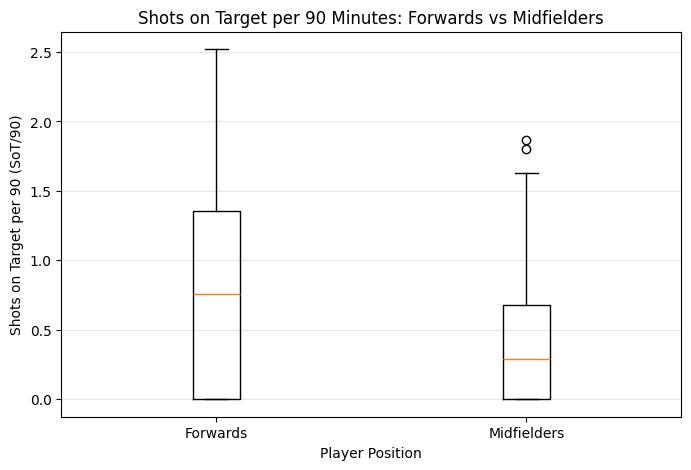

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.boxplot(
    [forward_sample["SoT/90"], midfielder_sample["SoT/90"]],
    tick_labels=["Forwards", "Midfielders"]
)

plt.title("Shots on Target per 90 Minutes: Forwards vs Midfielders")
plt.ylabel("Shots on Target per 90 (SoT/90)")
plt.xlabel("Player Position")
plt.grid(axis="y", alpha=0.3)

plt.show()

Figure Interpretation: The simple boxplot looks pretty straightforward and is best shown on a separate plot – here the distribution of SoT/90 looks to be generally higher for the Forwards sample than the Midfielders sample. (As well as the typical representation of a boxplot showing the central value of the sample, here it also makes clear that the sample’s median SoT/90 was also higher for the Forwards than the Midfielders.) The plot also conveys the fact that there were some relatively high values in the distribution of the samples for the Midfielders. All of this is shown in the simple plot above and, in more detail, in the preceding descriptive statistics. But for a formal test of difference between the two samples’ SoT/90, we also require a t-test.


13.⁠ ⁠Conclusion

We have chosen to investigate the difference between shooting performance of forwards and midfielders from FIFA World Cup 2026 by utilizing a random sample of 50 players in each position group.

The mean for forwards was 0.813 SoT/90 and for midfielders 0.443 SoT/90. The 95% CI for the two group means were 0.616 – 1.011 for forwards and 0.283 – 0.603 for midfielders. The results of the two-sample t-test were t = 2.924 and p = 0.0043.

Since the p-value is less than 0.05, we can reject the null hypothesis of the test and we are able to confirm the existence of a difference in mean SoT/90 between the two groups. The mean for forwards for this metric is higher.



Limitations
The analysis only utilized the metric SoT/90, thus other metrics of shooting were not investigated. The analysis also treated individual positions (i.e. Forwards, Midfielders, Defenders) as well as individuals with combined positions (i.e. Goal Scout, Right Winger) separately. In addition, players with less than 90 minutes of recorded action were also excluded from the analysis. Thus the results must be interpreted in the context of the defined population and the specific criteria used for the selection of players for analysis.
